In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv("../data/Fitbit_dataset.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
df.drop(columns=["Unnamed: 0"], inplace=True, errors="ignore")
print(df.columns)

   Unnamed: 0  Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  \
0           0   56  Female         53.8        1.62      163      149   
1           1   46    Male         54.9        1.75      170      126   
2           2   32  Female         68.5        1.61      190      171   
3           3   25    Male         98.8        1.86      189      135   
4           4   38    Male         95.5        1.71      176      138   

   Resting_BPM  Session_Duration (hours) Workout_Type  Fat_Percentage  \
0           71                      1.01         HIIT            22.1   
1           73                      0.25         Yoga            19.9   
2           60                      0.33         HIIT            20.4   
3           69                      0.78         Yoga            30.3   
4           66                      0.55       Cardio            23.7   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level  \
0                    3.5                     

In [10]:
cluster_df = df.drop(columns=["Workout_Type","Calories_Burned (kcal)"])
print(cluster_df.head())
print(cluster_df.columns)

   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56  Female         53.8        1.62      163      149           71   
1   46    Male         54.9        1.75      170      126           73   
2   32  Female         68.5        1.61      190      171           60   
3   25    Male         98.8        1.86      189      135           69   
4   38    Male         95.5        1.71      176      138           66   

   Session_Duration (hours)  Fat_Percentage  Water_Intake (liters)  \
0                      1.01            22.1                    3.5   
1                      0.25            19.9                    3.4   
2                      0.33            20.4                    2.7   
3                      0.78            30.3                    4.4   
4                      0.55            23.7                    2.2   

   Workout_Frequency (days/week)  Experience_Level   BMI  Base_MET  \
0                              3                 1  20.4       9

In [11]:
cluster_df = pd.get_dummies(cluster_df, columns= ["Gender"], drop_first = True)
print(cluster_df.head())
print(cluster_df.dtypes)

   Age  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56         53.8        1.62      163      149           71   
1   46         54.9        1.75      170      126           73   
2   32         68.5        1.61      190      171           60   
3   25         98.8        1.86      189      135           69   
4   38         95.5        1.71      176      138           66   

   Session_Duration (hours)  Fat_Percentage  Water_Intake (liters)  \
0                      1.01            22.1                    3.5   
1                      0.25            19.9                    3.4   
2                      0.33            20.4                    2.7   
3                      0.78            30.3                    4.4   
4                      0.55            23.7                    2.2   

   Workout_Frequency (days/week)  Experience_Level   BMI  Base_MET  \
0                              3                 1  20.4       9.5   
1                              3          

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)
print(type(scaled_data))
print(scaled_data.shape)

<class 'numpy.ndarray'>
(14102, 16)


In [13]:
from sklearn.decomposition import PCA 
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
print(pca_data.shape)
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

(14102, 2)
[0.24649286 0.22565436]
0.4721472216809981


In [14]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_data)
print(clusters[:10])
print(set(clusters))



[0 1 0 1 0 1 1 0 0 0]
{np.int32(0), np.int32(1), np.int32(2)}


In [15]:
pca_df = pd.DataFrame(data=pca_data, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters
print(pca_df.head())
print(pca_df["Cluster"].value_counts())


        PC1       PC2  Cluster
0 -0.924919  1.387252        0
1 -0.087197 -3.762391        1
2 -2.247167  2.355759        0
3  0.178343 -2.867094        1
4 -1.592230 -1.385689        0
Cluster
0    6289
2    4321
1    3492
Name: count, dtype: int64


In [16]:
from sklearn.metrics import silhouette_score
score = silhouette_score(pca_data,clusters)
print("Silhouette Score:", score)



Silhouette Score: 0.38056211989564914


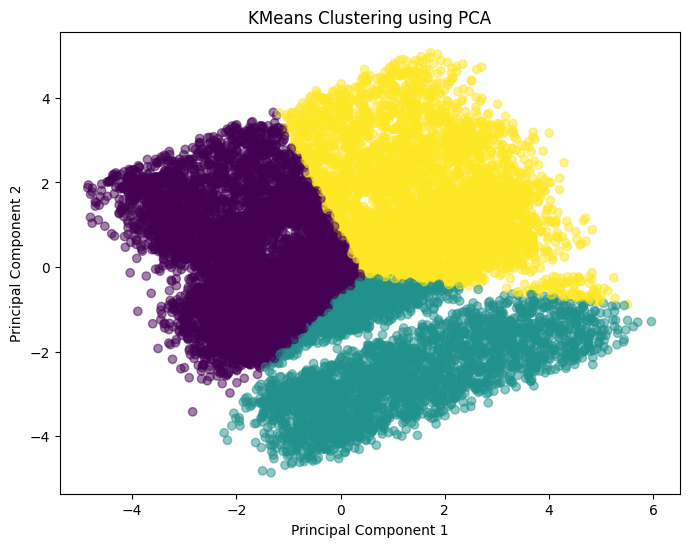

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["Cluster"], alpha=0.5)
plt.title("KMeans Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()


In [19]:
cluster_df["Cluster"] = clusters
cluster_summary = cluster_df.groupby("Cluster").mean()
print(cluster_summary)

cluster_summary.to_csv(
    "../output/cluster_summary.csv",
    index=True
)

print("Cluster summary saved successfully!")

               Age  Weight (kg)  Height (m)     Max_BPM     Avg_BPM  \
Cluster                                                               
0        37.196057    68.375020    1.680184  182.988233  154.850533   
1        41.909507    68.381787    1.681964  177.468786  131.661226   
2        37.735015    67.971072    1.679246  182.267994  151.088405   

         Resting_BPM  Session_Duration (hours)  Fat_Percentage  \
Cluster                                                          
0          73.435363                  0.659836       25.133423   
1          69.476518                  0.815633       22.199255   
2          63.246471                  1.089715       16.770331   

         Water_Intake (liters)  Workout_Frequency (days/week)  \
Cluster                                                         
0                     3.302608                       3.055335   
1                     3.741123                       4.085911   
2                     3.914302                       